In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import tensorflow as tf
from keras import Sequential
from keras.layers import SimpleRNN, Dense, Input

In [ ]:
x = np.arange(0,100, 0.1)                                 # 0~100까지 0.1 간격으로 차례로 1000개의 일련의 숫자를 생성해서 x에 할당
y = 0.5 * np.sin(2*x) - np.cos(x/2.0)                     # 별도 랜덤 테스트 :  y = np.random.rand(len(x))              # x의 갯수만큼 무작위의 실수 y 데이터를 생성

seq_data = y.reshape(-1,1)

print(seq_data.shape)

In [ ]:
plt.figure(figsize=(15,3))

plt.plot(seq_data)
plt.xlabel('No.')
plt.ylabel('Value')
plt.grid()
plt.show()

In [ ]:
def seq2dataset(seq, window, horizon):
  X = []
  Y = []

  for i in range(len(seq)-(window+horizon)+1):                                  # 1000-(50+1)+1 : 950번 반복
    x = seq[i:(i+window)]                                                       # y data (seq_data) 중에서 0부터 49번째까지 50개를 잘라서 x에 할당
    y = seq[i+window+horizon-1]                                                 # y data (seq_data) 중에서 50번째를 y에 할당 (앞에 50개를 통해서 51번째를 예측할 거니까)

    X.append(x)                                                                 # 50개를 1개의 세트로 잘라서 X에 추가해 나감 (X는 50개짜리 연속데이터(1세트)가 950세트 들어감)
    Y.append(y)                                                                 # Y에는 50개짜리 데이터의 그 다음 숫자 1개씩이 950개 들어감
  return np.array(X), np.array(Y)

w = 10                                                                          # window size(기본 50)를 증가시며가며 관찰
h = 1                                                                           # 얼마나 멀리 예측할 것인가?
X, Y = seq2dataset(seq_data, w, h)
print(X.shape, Y.shape)

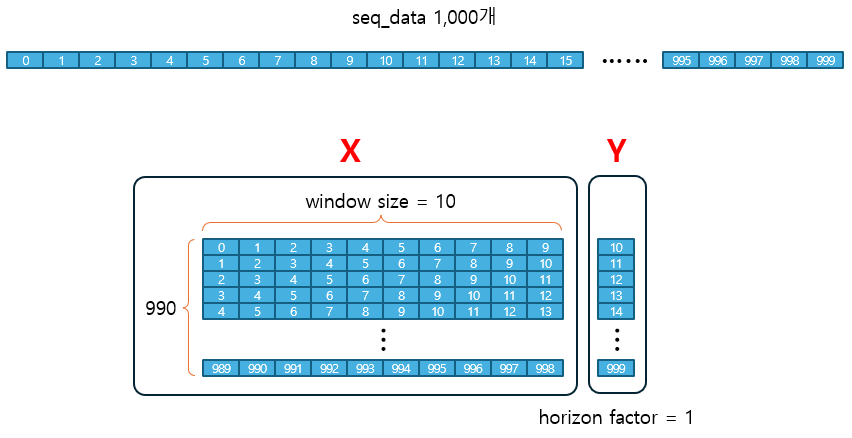

In [ ]:
split_ratio = 0.7

split = int(split_ratio * len(X))                                               # 950개 데이터중에 split_ratio(0.7)의 비율로 분리 예정

x_train = X[0:split]                                                            # 950세트의 X data중에서 70%를 x_train에 할당
y_train = Y[0:split]                                                            # 950개의 Y data중에서 70%를 y_train에 할당

x_test = X[split:]                                                              # 30%는 test data로 할당
y_test = Y[split:]

print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

In [ ]:
x_train[0].shape

 ################ unit을 단계적으로 상향

In [ ]:
model = Sequential()

model.add(Input(shape=(x_train[0].shape)))
model.add(SimpleRNN(units=1, activation='tanh'))                                # 기본 units=128, units을 1부터 차례로 증가시켜가며 파라미터 변화와 fit 특성 관찰
model.add(Dense(1))                                                             # weight sharing 설명

model.compile(loss='mse', optimizer='adam', metrics=['mae'])
model.summary()

In [ ]:
hist = model.fit(x_train, y_train, epochs=200, validation_split=0.1)

In [ ]:
plt.figure(figsize=(5,3))

plt.plot(hist.history['loss'], label='train loss')
plt.plot(hist.history['val_loss'], label='valivation loss')

plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')

plt.legend(loc='best')
plt.grid()
plt.show()

In [ ]:
pred_train = model.predict(x_train)
pred_test = model.predict(x_test)

print(pred_train.shape)
print(pred_test.shape)

In [ ]:
plt.figure(figsize=(15,3))

plt.plot(pred_test, label='prediction')
plt.plot(y_test, label='label')
# plt.xlim(0,1000)

plt.legend(loc='best')
plt.grid()
plt.show()

In [ ]:
plt.figure(figsize=(15,3))

all_actual = np.concatenate((y_train, y_test), axis=0)
all_predictions = np.concatenate((pred_train, pred_test), axis=0)

plt.plot(all_actual, label='Actual Values', color='blue', alpha=0.7)
plt.plot(all_predictions, label='Predicted Values', color='red', alpha=0.7)

plt.axvline(x=len(y_train) - 1, color='green', linestyle='--', label='Train/Test Split')          # Add a vertical line to indicate the train/test split

plt.title('Actual vs. Predicted Values (Train and Test Sets)')
plt.xlabel('Data Point Index')
plt.ylabel('Value')

plt.legend(loc='best')
plt.grid()
plt.show()

Random data로 다시 학습 및 결과 확인